In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [39]:
data = pd.read_csv("/content/labelled_data.csv")\
        .drop(columns="Unnamed: 0")
data.head()

,comment_id,author,text,likes,published_at,vader_neg,vader_neu,vader_pos,vader_compound,roberta_neg,roberta_neu,roberta_pos,vader_label,roberta_label,pipeline_label
0,UgwoiJ6zDlEHgNHbKHl4AaABAg,@SalekaAsuna,Mike is the most traumatic in this season his ...,0,2025-12-27T02:17:44Z,0.128,0.818,0.054,-0.5314,0.971900,0.025935,0.002164,negative,negative,negative
1,UgyXJRcSbn74ajhkmBN4AaABAg,@tofuzu,"this was so bad yall. wth was that writing, th...",0,2025-12-27T02:13:56Z,0.278,0.722,0.000,-0.9460,0.975026,0.022050,0.002924,negative,negative,negative
2,UgzhXrqNFCkMLMOB6dh4AaABAg,@JD-xn1cx,Not a single shot from final episode,0,2025-12-27T01:51:33Z,0.000,1.000,0.000,0.0000,0.390147,0.579394,0.030459,neutral,neutral,negative
3,UgxQPzUbRC8ECcXroFF4AaABAg,@ravenr876,Rated J for Jesus: A Box Office Blasphemy – Ho...,0,2025-12-27T01:35:21Z,0.167,0.833,0.000,-0.2960,0.299472,0.592630,0.107898,negative,neutral,positive
4,UgzQIyIMuD3WZha30dd4AaABAg,@ravenr876,Does Hollyweird ever stop attacking Christiani...,0,2025-12-27T01:30:37Z,0.382,0.618,0.000,-0.9186,0.972716,0.024830,0.002454,negative,negative,positive


In [6]:
# drop unnecessary columns
data.columns

Index(['comment_id', 'author', 'text', 'likes', 'published_at', 'vader_neg',
       'vader_neu', 'vader_pos', 'vader_compound', 'roberta_neg',
       'roberta_neu', 'roberta_pos', 'vader_label', 'roberta_label',
       'pipeline_label'],
      dtype='object')

In [40]:
data = data[["comment_id", "text", "published_at", "roberta_neg", "roberta_neu", "roberta_pos", "roberta_label"]]

In [4]:
data.to_csv("project_data.csv")

In [9]:
data.isna().sum()
# no null values

,0
comment_id,0
text,0
published_at,0
roberta_neg,0
roberta_neu,0
roberta_pos,0
roberta_label,0


In [10]:
data.duplicated().sum()
# no duplicates

np.int64(0)

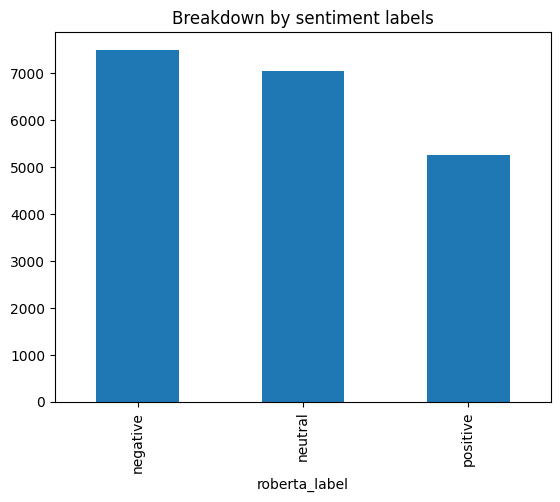

In [16]:
data["roberta_label"].value_counts().plot(kind="bar", label=True)
plt.title("Breakdown by sentiment labels")
plt.show()

In [41]:
data["text"] = data["text"].str.strip().str.lower()

In [24]:
data["text"].sample().values[0]

'someone has to do it so that will be me. the one piece is real'

In [42]:
import re

def remove_urls(text: str) -> str:
    """
    Remove URLs from a text string.
    """
    url_pattern = r'https?://\S+|www\.\S+'
    return re.sub(url_pattern, '', text).strip()

# applying remove_urls function to text column
data["text"] = data["text"].apply(remove_urls)

In [43]:
# removing newline character
data["text"] = data["text"].str.replace("\n", "", regex=True)

In [44]:
data["roberta_label"].value_counts(normalize=True) * 100

# all the classes are roughly balanced

,proportion
roberta_label,
negative,37.852566
neutral,35.602200
positive,26.545234


In [44]:
data["num_words"] = data["text"].apply(lambda x: len(x.split()))

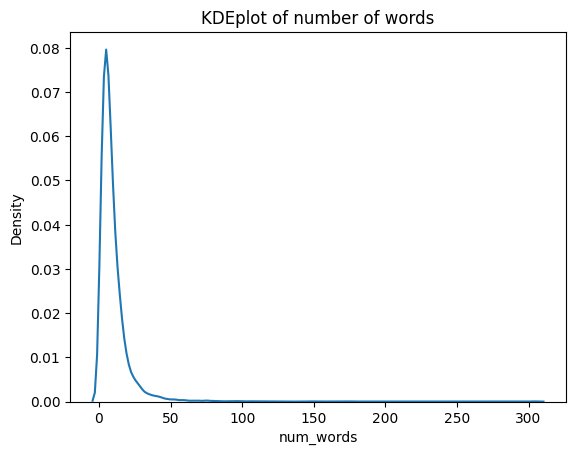

In [53]:
sns.kdeplot(data["num_words"])
plt.title("KDEplot of number of words")
plt.show()

- number of words is right skewed - many comments have between 0 and 50 words but a few comments also have around 300 words

In [9]:
pip install emoji


In [45]:
import emoji

def emojis_to_text(text: str) -> str:
    """
    Convert emojis in text to their textual descriptions.
    Example: 😍🔥 -> smiling_face_with_heart_eyes fire
    """
    return emoji.demojize(text, delimiters=(" ", " "))


In [11]:
comment = "This video is amazing 😍🔥🔥"
cleaned = emojis_to_text(comment)

print(cleaned)

This video is amazing  smiling_face_with_heart-eyes  fire  fire 


In [57]:
data.sample(10)

,comment_id,text,published_at,roberta_neg,roberta_neu,roberta_pos,roberta_label,num_words
19783,UgzDjaUCm97dXTqZlvJ4AaABAg,pin me netflix please i love u,2025-12-15T13:40:55Z,0.003959,0.031712,0.964329,positive,7
8182,UgxV52X2tQ8UfDP1RzF4AaABAg,🔥,2025-12-15T19:50:50Z,0.103854,0.385979,0.510167,positive,1
13467,UgwwRiQWTp951l4G9Wp4AaABAg,"“if you die, i die” just don’t die plzz😢",2025-12-15T15:27:29Z,0.801237,0.178388,0.020375,negative,9
14650,UgzCC1-IuuELcMqEztN4AaABAg,netflix ragebaiting us 😂❤,2025-12-15T15:01:00Z,0.151129,0.467139,0.381732,neutral,4
11471,Ugxilsjwr5lZQXJOKa94AaABAg,o shih i don't want to see steve and dustin de...,2025-12-15T16:22:37Z,0.933783,0.060662,0.005555,negative,11
9258,UgwjGp1H6o-2o9Qf3wR4AaABAg,you know its gonna be good when you see nancy ...,2025-12-15T17:55:41Z,0.021840,0.223676,0.754484,positive,13
8420,Ugz-9jhM4h8nXb1UWQp4AaABAg,the most epic stranger things trailer we’ve ev...,2025-12-15T19:16:30Z,0.003208,0.068812,0.927980,positive,9
1987,UgwIQSxixMs7NamaMHp4AaABAg,omgggg im ready,2025-12-17T21:24:33Z,0.022541,0.298535,0.678924,positive,3
2888,UgxUxSXFIKTmwTSFa_J4AaABAg,i hope lucas dies he’s a useless character,2025-12-16T21:58:25Z,0.945491,0.047333,0.007176,negative,8
16214,UgychAOpitXSpfUk15F4AaABAg,mother of god 😮‍💨,2025-12-15T14:34:07Z,0.022257,0.553317,0.424427,neutral,4


In [12]:
sample_df = data.loc[[8182, 13467, 14650, 16214], "text"]
sample_df

,text
8182,🔥
13467,"“if you die, i die” just don’t die plzz😢"
14650,netflix ragebaiting us 😂❤
16214,mother of god 😮‍💨


In [64]:
sample_df.values

array(['🔥', '“if you die, i die” just don’t die plzz😢',
       'netflix ragebaiting us 😂❤', 'mother of god 😮\u200d💨'],
      dtype=object)

In [13]:
for text in sample_df.values:
  print(emojis_to_text(text))

 fire 
“if you die, i die” just don’t die plzz crying_face 
netflix ragebaiting us  face_with_tears_of_joy  red_heart 
mother of god  face_exhaling 


### Punctuation marks
- some punctuation marks are important to convey sentiment: !!!, or
??? convery intense sentiment.
- if a sentence is written in all capital letters, it suggests strong emotions of excitement or anger

In [46]:
def normalize_punctuation(text: str) -> str:
    # Normalize repeated exclamation & question marks
    text = re.sub(r'!{2,}', '!', text)
    text = re.sub(r'\?{2,}', '?', text)

    # Remove all punctuation except ! and ?
    text = re.sub(r'[^\w\s!?]', '', text)

    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

# this function removes URLs, converts emojis to text and then removes unnecessary punctuation marks like , and "".
def clean_comment(text: str) -> str:
    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Convert emojis to text
    text = emoji.demojize(text, delimiters=(" ", " "))

    # Normalize punctuation
    text = normalize_punctuation(text)

    return text

In [15]:
example = data["text"].sample().values[0]
print(example)
print(f"after preprocessing: {clean_comment(example)}")

i really hope we get to witness such greatness ever again. until this year i had never watched this show and now i’m suffering the end of it. what a masterpiece.
after preprocessing: i really hope we get to witness such greatness ever again until this year i had never watched this show and now im suffering the end of it what a masterpiece


In [47]:
data["text"] = data["text"].apply(clean_comment)

In [48]:
def normalize_punctuation(text: str) -> str:
    """
    Normalize punctuation in a string:
    - Replace smart quotes and unicode punctuation with standard ones
    - Remove all other punctuation except letters, numbers, spaces, !, and ?
    - Normalize multiple spaces
    """
    if not isinstance(text, str):
        return ""

    # Replace common smart/unicode punctuation
    replacements = {
        "’": "'", "‘": "'", "“": '"', "”": '"',
        "–": "-", "—": "-", "…": "...", "•": "-", "′": "'", "″": '"'
    }
    for k, v in replacements.items():
        text = text.replace(k, v)

    # Remove all punctuation except letters, numbers, spaces, ! and ?
    text = re.sub(r'[^\w\s!?]', '', text)

    # Normalize multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

  # demo of how normalize punctuation works
  normalize_punctuation("I swear Robin’s girlfriend is gonna die")

In [56]:
data["text"] = data["text"].apply(normalize_punctuation)

- There are some comments that are not in english.
- I could either remove non-english comments or detect the language of that comment and convert it to english
- For the sake of this project, I'm going to remove non-english comments

In [17]:
# installing langdetect
!pip install langdetect

In [19]:
from langdetect import detect, DetectorFactory

DetectorFactory.seed = 0  # for consistent results

def is_english(text: str) -> str:
    """
    Return the text if English, otherwise return "NON_ENGLISH".
    """
    try:
        if detect(text) == 'en':
            return text
        else:
            return "non-english"
    except:
        return "non_english"

# demo of how is_engish() works
comments = [
    "This video is amazing 😍",
    "Este video es increíble",
    "C'est trop bien"
]

for c in comments:
    print(c, is_english(c))

This video is amazing 😍 This video is amazing 😍
Este video es increíble non-english
C'est trop bien non-english


In [57]:
from tqdm import tqdm
# applying tqdm to pandas
tqdm.pandas()

data["text"] = data["text"].progress_apply(is_english)

100%|██████████| 19819/19819 [01:26<00:00, 229.65it/s]


In [25]:
data[data["text"] == "non-english"].shape

(5423, 8)

5500 rows had non-english comments

In [32]:
nonenglish_indices = data[data["text"] == "non-english"].index.to_list()

In [ ]:
# importing original data to see which comments have been labelled as no-nenglish
original_Data= pd.read_csv("./labelled_data.csv")

In [34]:
nonenglish_texts = original_data.loc[nonenglish_indices, "text"]

In [35]:
nonenglish_texts.to_csv("./non_english_comments.csv")

- Langdetect flagged ~28% of the comments as non-english.
- This is a lot of data so I inspected the comments that were being flagged as non-english.
- it turns out that while there are some comments that truly are in some other language, a decent amount of comments that are being flagged to be non-english are comments like "YYAYYYAA" or  "OMGGGGG" or "Robin's girlfriend". Now comments that exagerrate common english words like peak or omg or yay can be manually changed to be flagged as english.
- A common issue was that many comments that were fully in english were flagged to be non-english because of non-standard punctuation marks so fixing those non standard punctuation marks should help.

In [49]:
processed = normalize_punctuation("I swear Robin’s girlfriend is gonna die")

'non-english'

In [50]:
normalize_punctuation("I swear Robin’s girlfriend is gonna die")

'I swear Robins girlfriend is gonna die'

In [52]:
is_english(processed)

'non-english'

row ids with non-english comments after manual inspection:
71, 141, 181, 212,230, 294, 373, 576, 587, 598, 614, 618, 638, 714, 731, 798, 1074, 1336, 1389, 1466, 1605, 1706, 1792, 1893, 2289, 2317, 2356, 2359, 2423, 230, 2533, 2617, 2684, 2721, 2845, 2847, 2854, 2857, 3058, 3076, 3093, 3258, 3889, 3922, 3924, 3967, 3970, 4001, 4326, 4353, 4436, 4616, 4800, 4952, 4966, 5176, 5178, 5280, 6014, 6036, 6113, 6128, 6178, 6280, 6400, 6558, 6589, 7326, 7361, 7454, 7472, 7572, 7583, 7593, 7608, 7704, 7819, 7981, 8171, 8207, 8289, 8317, 8319, 8379, 8380, 8428, 8458, 8469, 8495, 8522, 8607, 8758, 8788, 8880, 8938, 8944, 8996, 9067, 9170, 9179, 9202, 9208, 9233, 9357, 9727, 9749, 9794, 9798, 9811, 9816, 9834, 9848, 9936, 10025, 10085, 10090, 10094, 10098, 10196, 10249, 10263, 10309, 10343, 10450, 10470, 10473, 10621, 10680, 10776, 10827, 10944, 10998, 11193, 11220, 11257, 11399, 11591, 11605, 11630, 11633, 11772, 11944, 12044, 12199, 12379, 12419, 12542, 12583, 12636, 12721, 12825, 13071, 13114, 13134, 13267, 13290,13333, 13395, 13406, 13422, 13424, 13438, 13469, 13500, 13514, 13726, 13870, 14034, 14060, 14487, 14506, 14521, 14545, 14590, 14680, 14738, 14780, 14898, 14992, 15001, 15089, 15102, 15172, 15585, 15665, 15675, 15726, 15836, 16008, 16107, 16123, 161 16396, 16687, 16750, 17033, 17325, 17428, 17473, 17483, 17494, 17658, 17665, 18028, 18118, 18247, 18327, 18673, 18966, 19012, 19066, 19255, 19493, 19523, 19532, 19580, 19687, 19689,